# Análise Inicial: Acidentes de Trânsito em SP

Análise exploratória dos dados do Infosiga SP armazenados no PostgreSQL/PostGIS.

**Colunas disponíveis:** `tipo_acidente` (tipo primário do sinistro), `causa_acidente` (tipo de via),
`mortos`, `feridos_graves`, `feridos_leves`, `turno`, `tipo_local`, `dia_semana`, `hora`, `regiao_administrativa`

---

## 1. Setup

In [1]:
!pip install geopandas folium psycopg2-binary sqlalchemy GeoAlchemy2 mapclassify matplotlib seaborn --quiet
print('Dependências OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 2.6 MB/s eta 0:00:00
Dependências OK


In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium, warnings
from folium.plugins import HeatMap
warnings.filterwarnings('ignore')
from sqlalchemy import create_engine, text

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Imports OK')

Imports OK


## 2. Conexão com o Banco

In [5]:
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'acidentes_sp'
DB_USER = 'postgres'
DB_PASS = 'postgres'
engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# Restaurar banco do Google Drive
from google.colab import drive
drive.mount('/content/drive')

!sudo apt-get install -y postgresql postgis > /dev/null 2>&1
!sudo service postgresql start
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';" > /dev/null 2>&1
!sudo -u postgres psql -c "CREATE DATABASE acidentes_sp;" > /dev/null 2>&1
!sudo -u postgres psql -d acidentes_sp -c "CREATE EXTENSION postgis;" > /dev/null 2>&1
!sudo -u postgres psql acidentes_sp < /content/drive/MyDrive/acidentes_sp_backup.sql
print('Banco restaurado!')

Mounted at /content/drive
 * Starting PostgreSQL 14 database server
   ...done.
SET
SET
SET
SET
SET
 set_config 
------------
 
(1 row)

SET
SET
SET
SET
CREATE EXTENSION
COMMENT
SET
SET
CREATE TABLE
ALTER TABLE
CREATE TABLE
ALTER TABLE
CREATE SEQUENCE
ALTER TABLE
ALTER SEQUENCE
ALTER TABLE
COPY 1243731
COPY 645
COPY 0
 setval 
--------
    645
(1 row)

ALTER TABLE
ALTER TABLE
CREATE INDEX
Banco restaurado!


## 3. Carga dos Dados

In [8]:
df = pd.read_sql("""
    SELECT id_sinistro, ano, mes, data_ocorrencia, dia_semana, hora, turno,
           tipo_local, municipio_nome, regiao_administrativa,
           tipo_acidente, causa_acidente,
           mortos, feridos_graves, feridos_leves, ilesos, total_vitimas,
           latitude, longitude
    FROM acidentes
    WHERE ano IS NOT NULL
""", engine)

df['data_ocorrencia'] = pd.to_datetime(df['data_ocorrencia'], errors='coerce')

gdf_mun = gpd.read_postgis(
    'SELECT codigo_ibge, nome, geom FROM municipios',
    engine, geom_col='geom'
).to_crs(epsg=4326)

print(f'{len(df):,} sinistros | {len(gdf_mun)} municípios')
print(f'   Período: {df["ano"].min()} – {df["ano"].max()}')
df.head(3)

1,243,731 sinistros | 645 municípios
   Período: 2014 – 2026


,id_sinistro,ano,mes,data_ocorrencia,dia_semana,hora,turno,tipo_local,municipio_nome,regiao_administrativa,tipo_acidente,causa_acidente,mortos,feridos_graves,feridos_leves,ilesos,total_vitimas,latitude,longitude
0,2073663,2019,5,2019-05-24,SEXTA-FEIRA,10:24,MANHA,PUBLICO,LINS,BAURU,COLISAO,VIAS URBANAS,0,0,1,0,1,-21.661614,-49.740685
1,1983517,2019,8,2019-08-03,SÁBADO,06:35,MANHA,PUBLICO,BAURU,BAURU,OUTROS,VIAS URBANAS,0,0,1,0,1,-22.275683,-49.060358
2,1715182,2021,4,2021-04-09,SEXTA-FEIRA,22:56,NOITE,PUBLICO,JAU,BAURU,OUTROS,VIAS URBANAS,0,1,0,0,1,-22.266783,-48.555791


## 4. Visão Geral dos Dados

In [9]:
print('=' * 55)
print('OVERVIEW DOS DADOS')
print('=' * 55)
print(f'  Sinistros registrados   : {len(df):>10,}')
print(f'  Municípios únicos       : {df["municipio_nome"].nunique():>10,}')
print(f'  Total de mortos         : {df["mortos"].sum():>10,}')
print(f'  Total feridos graves    : {df["feridos_graves"].sum():>10,}')
print(f'  Total feridos leves     : {df["feridos_leves"].sum():>10,}')
print(f'  Com coordenadas         : {df[["latitude","longitude"]].dropna().shape[0]:>10,}')
print('=' * 55)
print()
print('Tipos de sinistro (top 10):')
print(df['tipo_acidente'].value_counts().head(10).to_string())

OVERVIEW DOS DADOS
  Sinistros registrados   :  1,243,731
  Municípios únicos       :        645
  Total de mortos         :     52,283
  Total feridos graves    :     92,861
  Total feridos leves     :    796,798
  Com coordenadas         :  1,243,731

Tipos de sinistro (top 10):
tipo_acidente
COLISAO           525528
OUTROS            437033
ATROPELAMENTO     114551
CHOQUE             83583
NAO DISPONIVEL     83036


In [ ]:
df[['mortos','feridos_graves','feridos_leves','total_vitimas']].describe().round(2)

## 5. Série Temporal de Sinistros e Mortes

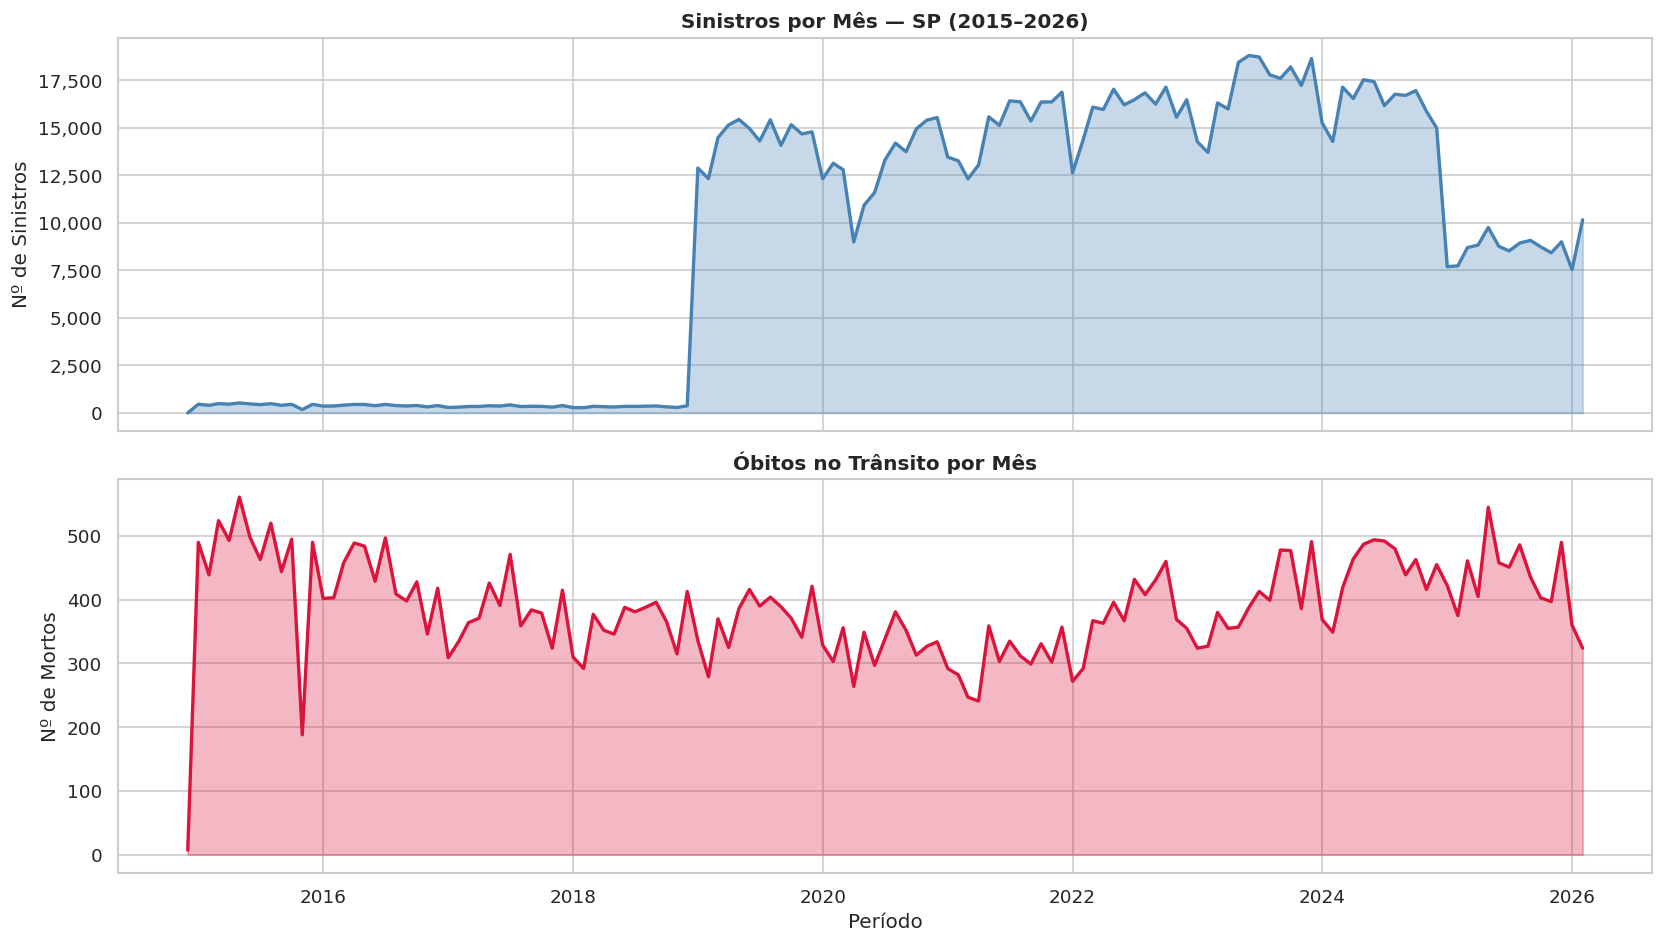

In [10]:
serie = df.groupby(['ano','mes']).agg(
    sinistros=('id_sinistro','count'),
    mortos=('mortos','sum'),
    feridos=('feridos_graves','sum')
).reset_index()
serie['periodo'] = pd.to_datetime(
    serie['ano'].astype(str) + '-' + serie['mes'].astype(str).str.zfill(2) + '-01'
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(serie['periodo'], serie['sinistros'], alpha=0.3, color='steelblue')
axes[0].plot(serie['periodo'], serie['sinistros'], color='steelblue', lw=2)
axes[0].set_title('Sinistros por Mês — SP (2015–2026)', fontweight='bold')
axes[0].set_ylabel('Nº de Sinistros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].fill_between(serie['periodo'], serie['mortos'], alpha=0.3, color='crimson')
axes[1].plot(serie['periodo'], serie['mortos'], color='crimson', lw=2)
axes[1].set_title('Óbitos no Trânsito por Mês', fontweight='bold')
axes[1].set_ylabel('Nº de Mortos')
axes[1].set_xlabel('Período')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('serie_temporal.png', bbox_inches='tight')
plt.show()

## 6. Top 20 Municípios com Mais Sinistros

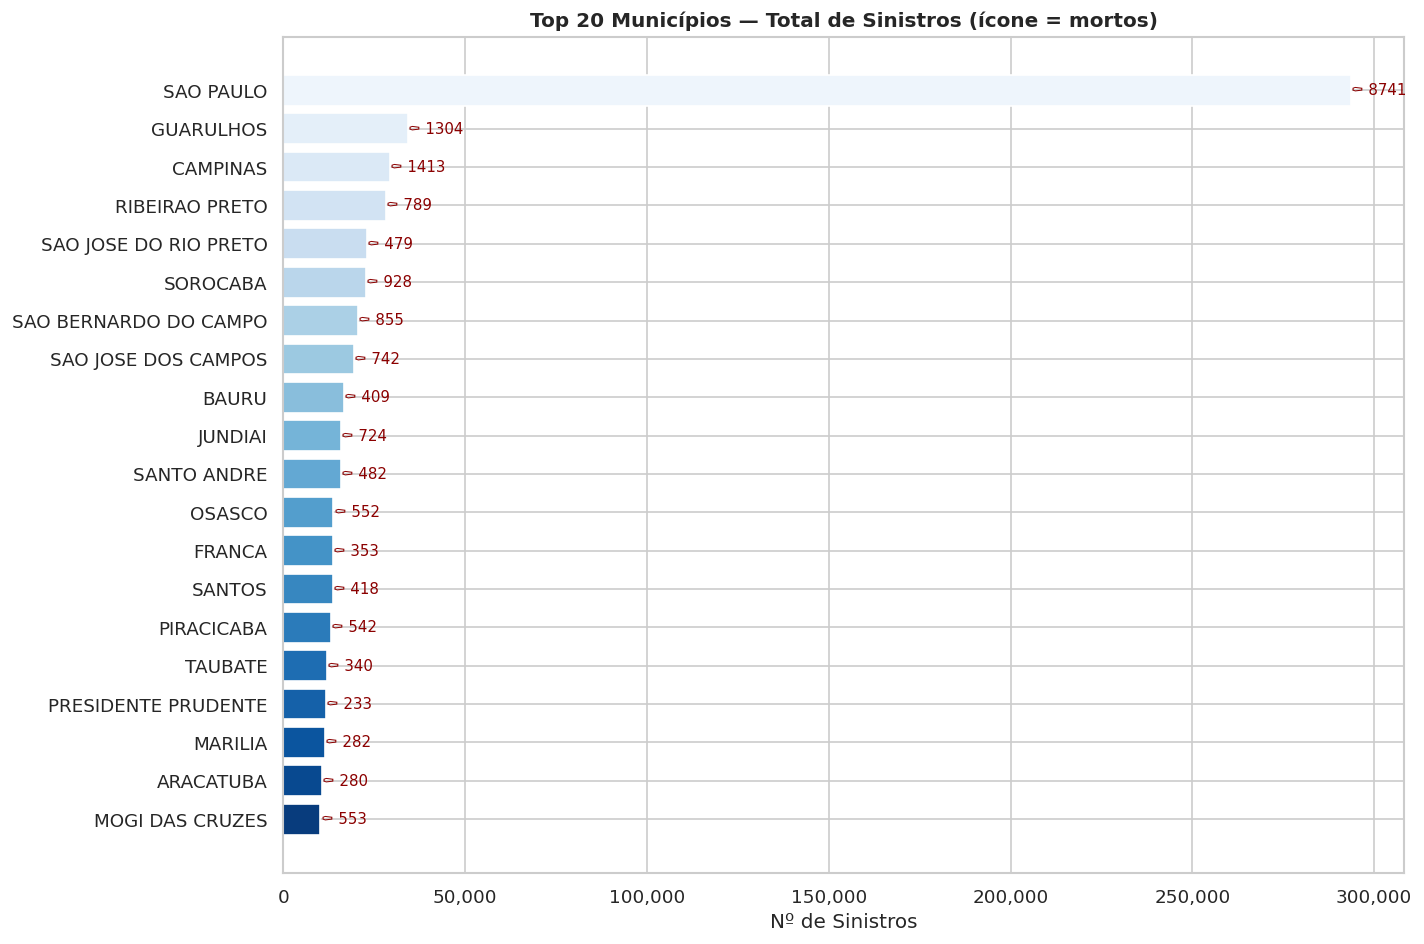

In [11]:
top20 = (
    df.groupby('municipio_nome')
    .agg(sinistros=('id_sinistro','count'), mortos=('mortos','sum'))
    .sort_values('sinistros', ascending=False)
    .head(20).reset_index()
)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20['municipio_nome'][::-1], top20['sinistros'][::-1],
        color=sns.color_palette('Blues_r', 20))
for i, (_, row) in enumerate(top20[::-1].iterrows()):
    ax.text(row['sinistros'] + 20, i, f"⚰ {int(row['mortos'])}",
            va='center', fontsize=9, color='darkred')
ax.set_title('Top 20 Municípios — Total de Sinistros (ícone = mortos)', fontweight='bold')
ax.set_xlabel('Nº de Sinistros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('top20_municipios.png', bbox_inches='tight')
plt.show()

## 7. Distribuição por Dia da Semana

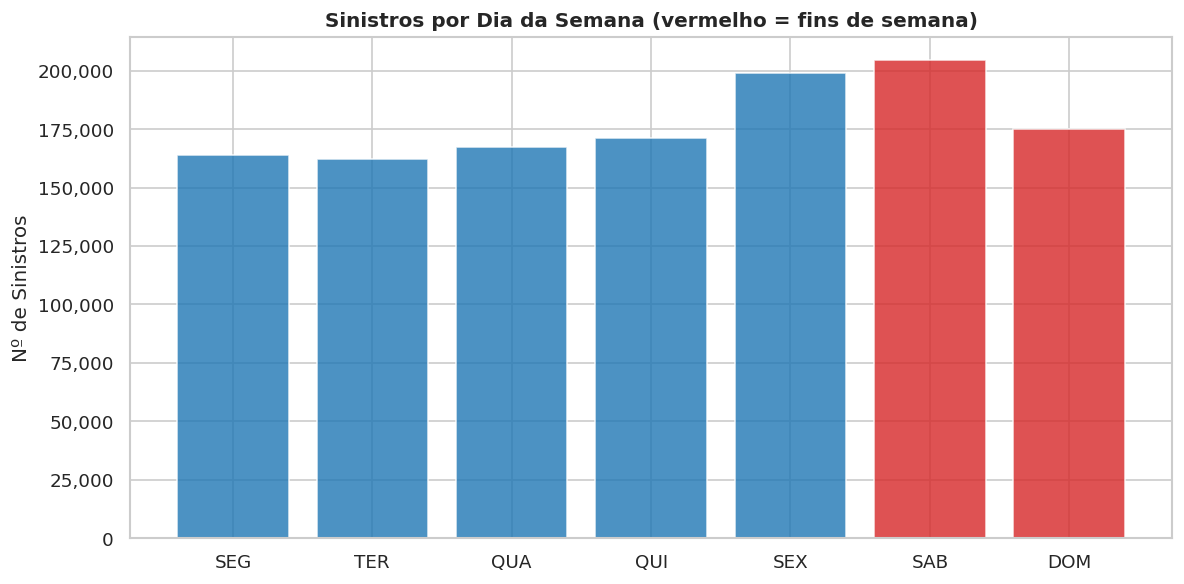

In [12]:
# Mapeamento flexível para os nomes do Infosiga
dia_map = {
    'SEGUNDA-FEIRA':'SEG','TERCA-FEIRA':'TER','TERÇA-FEIRA':'TER',
    'QUARTA-FEIRA':'QUA','QUINTA-FEIRA':'QUI','SEXTA-FEIRA':'SEX',
    'SABADO':'SAB','SÁBADO':'SAB','DOMINGO':'DOM',
    'SEGUNDA':'SEG','TERCA':'TER','QUARTA':'QUA',
    'QUINTA':'QUI','SEXTA':'SEX',
}
ordem = ['SEG','TER','QUA','QUI','SEX','SAB','DOM']
df['dia_norm'] = df['dia_semana'].map(dia_map).fillna(df['dia_semana'].str[:3])

dias = df.groupby('dia_norm').agg(
    sinistros=('id_sinistro','count'), mortos=('mortos','sum')
).reindex([d for d in ordem if d in df['dia_norm'].unique()])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(dias)), dias['sinistros'],
       color=['#d62728' if d in ['SAB','DOM'] else '#1f77b4' for d in dias.index],
       alpha=0.8)
ax.set_xticks(range(len(dias)))
ax.set_xticklabels(dias.index)
ax.set_title('Sinistros por Dia da Semana (vermelho = fins de semana)', fontweight='bold')
ax.set_ylabel('Nº de Sinistros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('dia_semana.png', bbox_inches='tight')
plt.show()

## 8. Distribuição por Turno e Tipo de Via

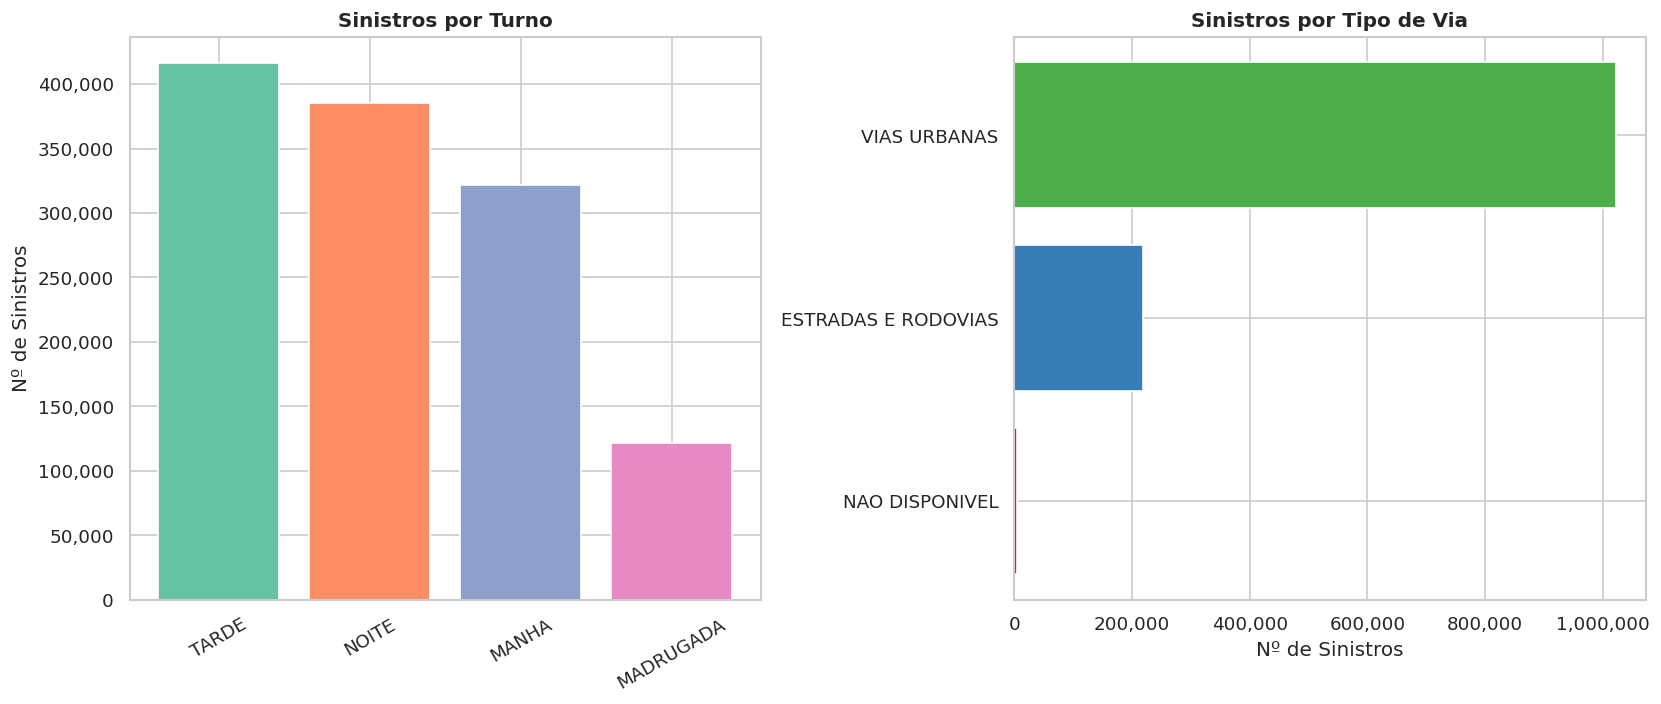

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Por turno
turno = df.groupby('turno').agg(sinistros=('id_sinistro','count'), mortos=('mortos','sum')).sort_values('sinistros', ascending=False)
axes[0].bar(turno.index, turno['sinistros'], color=sns.color_palette('Set2', len(turno)))
axes[0].set_title('Sinistros por Turno', fontweight='bold')
axes[0].set_ylabel('Nº de Sinistros')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Por tipo de via (causa_acidente)
via = df.groupby('causa_acidente').agg(sinistros=('id_sinistro','count'), mortos=('mortos','sum')).sort_values('sinistros', ascending=False).head(10)
axes[1].barh(via.index[::-1], via['sinistros'][::-1], color=sns.color_palette('Set1', len(via)))
axes[1].set_title('Sinistros por Tipo de Via', fontweight='bold')
axes[1].set_xlabel('Nº de Sinistros')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('turno_via.png', bbox_inches='tight')
plt.show()

## 9. Mapa Coroplético — Sinistros por Município

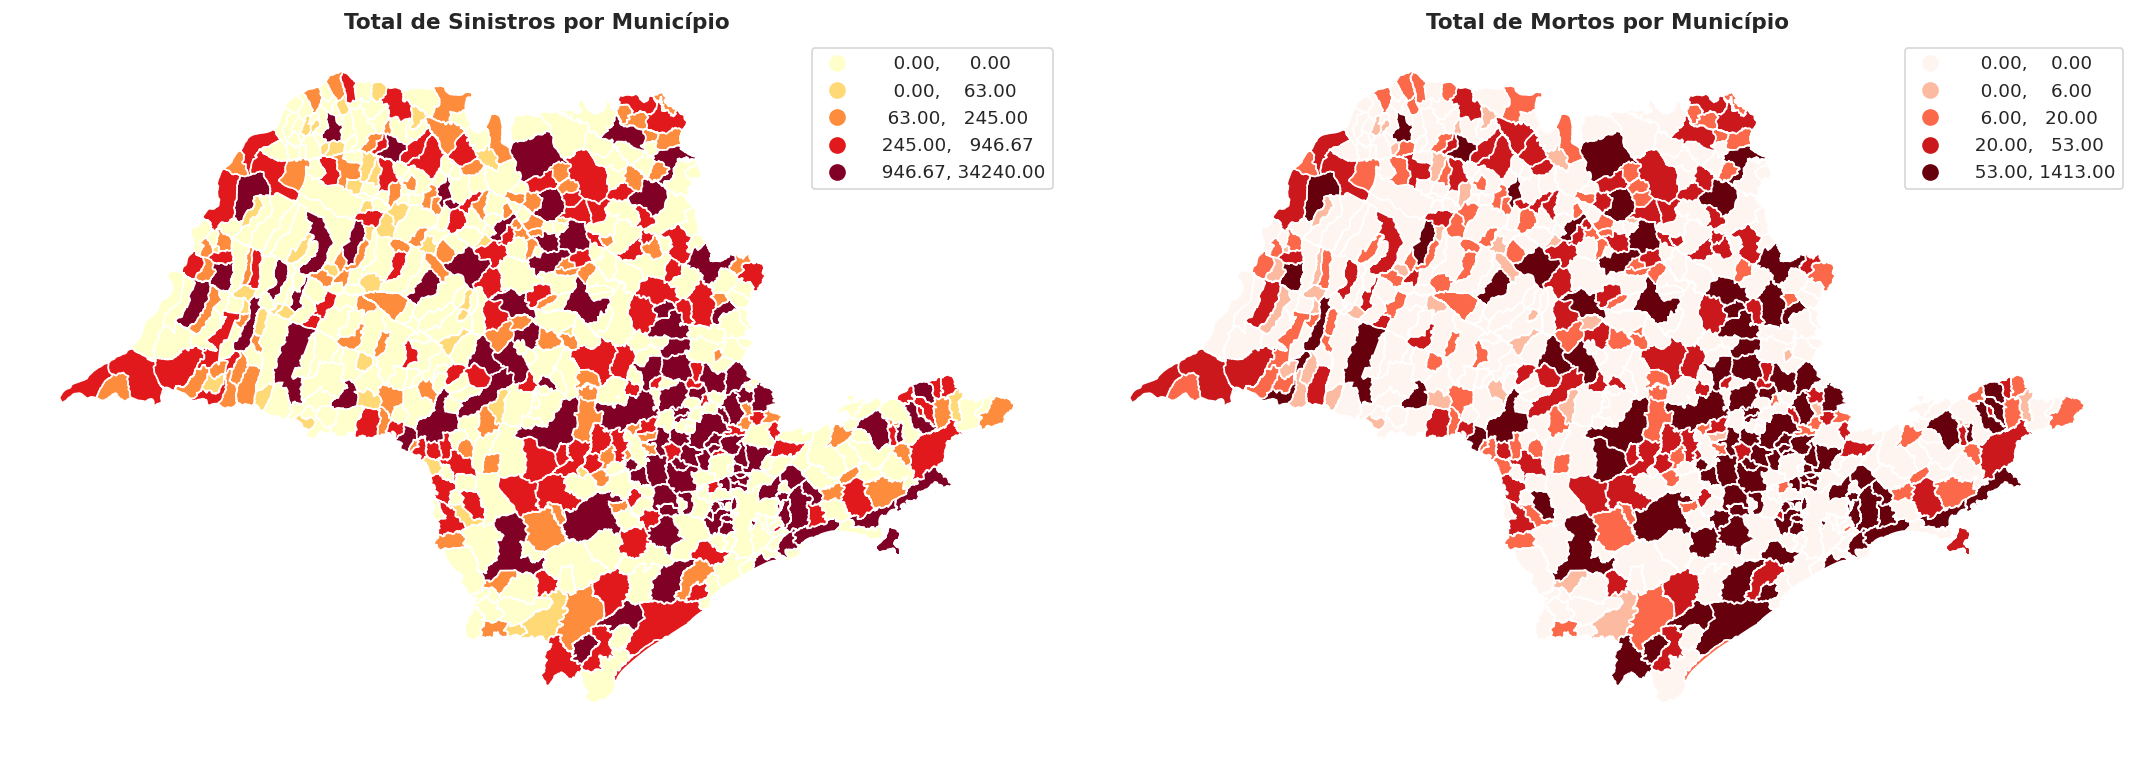

In [16]:
agg_mun = df.groupby('municipio_nome').agg(
    sinistros=('id_sinistro','count'), mortos=('mortos','sum')
).reset_index()

gdf_mun['nome_up'] = gdf_mun['nome'].str.upper().str.strip()
agg_mun['nome_up'] = agg_mun['municipio_nome'].str.upper().str.strip()
gdf_plot = gdf_mun.merge(agg_mun, on='nome_up', how='left').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

gdf_plot.plot(column='sinistros', ax=axes[0], legend=True, cmap='YlOrRd',
              scheme='quantiles', k=6)
axes[0].set_title('Total de Sinistros por Município', fontweight='bold', fontsize=13)
axes[0].axis('off')

gdf_plot.plot(column='mortos', ax=axes[1], legend=True, cmap='Reds',
              scheme='quantiles', k=6)
axes[1].set_title('Total de Mortos por Município', fontweight='bold', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('mapa_coropletico.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Mapa de Calor Interativo (Folium)

In [26]:
df_sample = df_geo.sample(n=50000, random_state=42)

mapa = folium.Map(location=[-22.5, -48.5], zoom_start=7, tiles='CartoDB positron')
HeatMap(df_sample[['latitude','longitude']].values.tolist(),
        radius=8, blur=10, max_zoom=13, min_opacity=0.4).add_to(mapa)

top5 = agg_mun.nlargest(5, 'sinistros')
for _, row in top5.iterrows():
    mun_geo = gdf_mun[gdf_mun['nome_up'] == row['nome_up']]
    if not mun_geo.empty:
        c = mun_geo.geometry.centroid.iloc[0]
        folium.CircleMarker(
            location=[c.y, c.x], radius=12, color='darkred',
            fill=True, fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>{row['municipio_nome']}</b><br>Sinistros: {int(row['sinistros']):,}<br>Mortos: {int(row['mortos']):,}",
                max_width=200)
        ).add_to(mapa)

# Salvar para entrega
mapa.save('mapa_calor.html')
print('mapa_calor.html salvo')

# Exibir no Colab via Google Colab nativo
from google.colab.output import eval_js
from IPython.display import display, HTML

mapa_html = mapa._repr_html_()
display(HTML(mapa_html))

mapa_calor.html salvo


## 11. Heatmap Dia da Semana × Hora

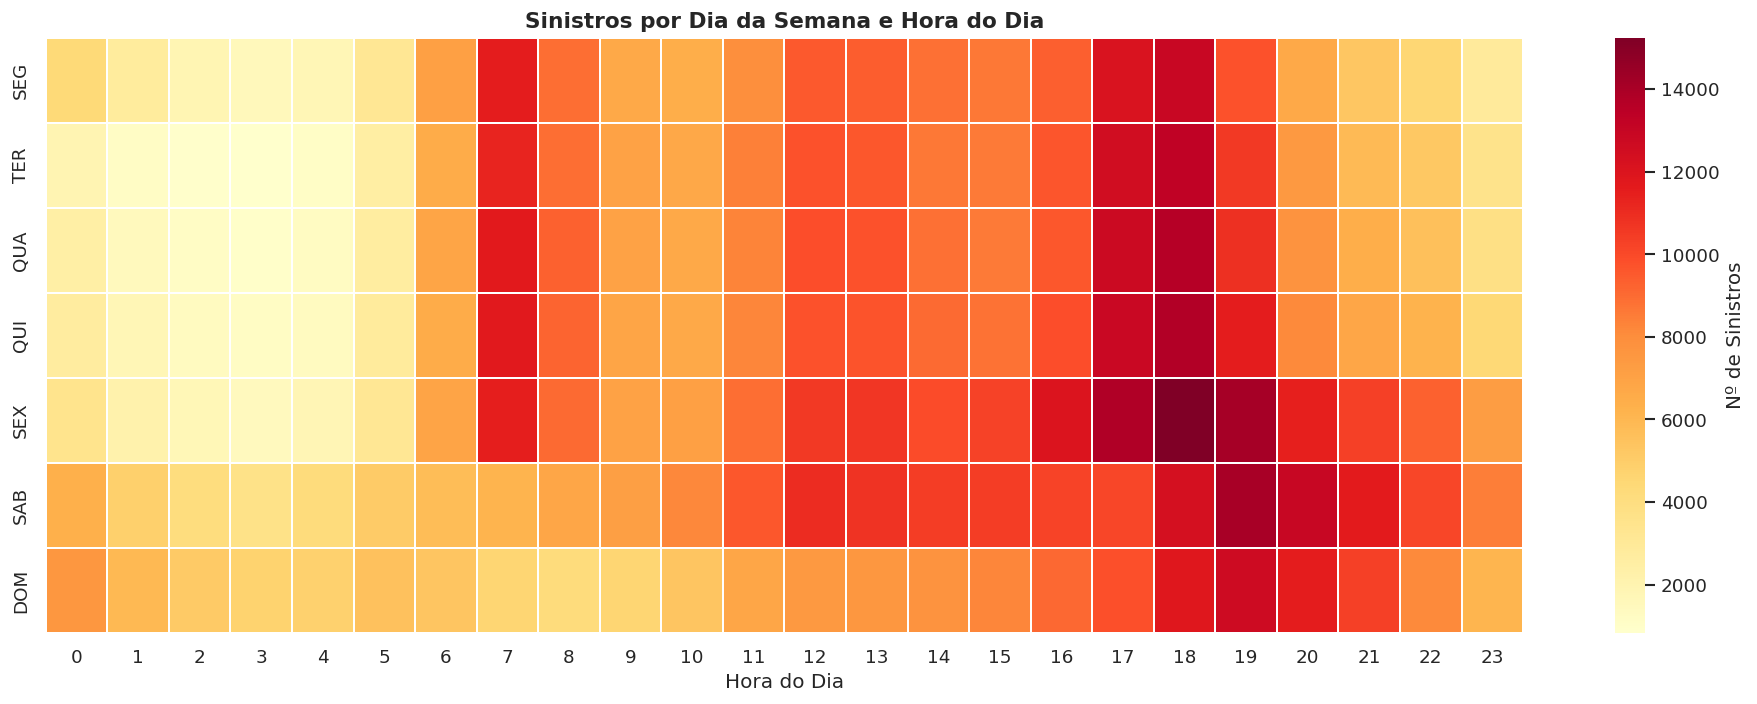

In [19]:
df['hora_num'] = pd.to_numeric(df['hora'].astype(str).str[:2], errors='coerce')
df_hora = df.dropna(subset=['hora_num','dia_norm'])
ordem = ['SEG','TER','QUA','QUI','SEX','SAB','DOM']
df_hora = df_hora[df_hora['dia_norm'].isin(ordem)]

pivot = df_hora.pivot_table(
    index='dia_norm', columns='hora_num',
    values='id_sinistro', aggfunc='count', fill_value=0
).reindex([d for d in ordem if d in df_hora['dia_norm'].unique()])

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.1,
            cbar_kws={'label':'Nº de Sinistros'})
ax.set_title('Sinistros por Dia da Semana e Hora do Dia', fontweight='bold', fontsize=13)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_hora.png', bbox_inches='tight')
plt.show()

## 12. Taxa de Mortalidade por Tipo de Sinistro

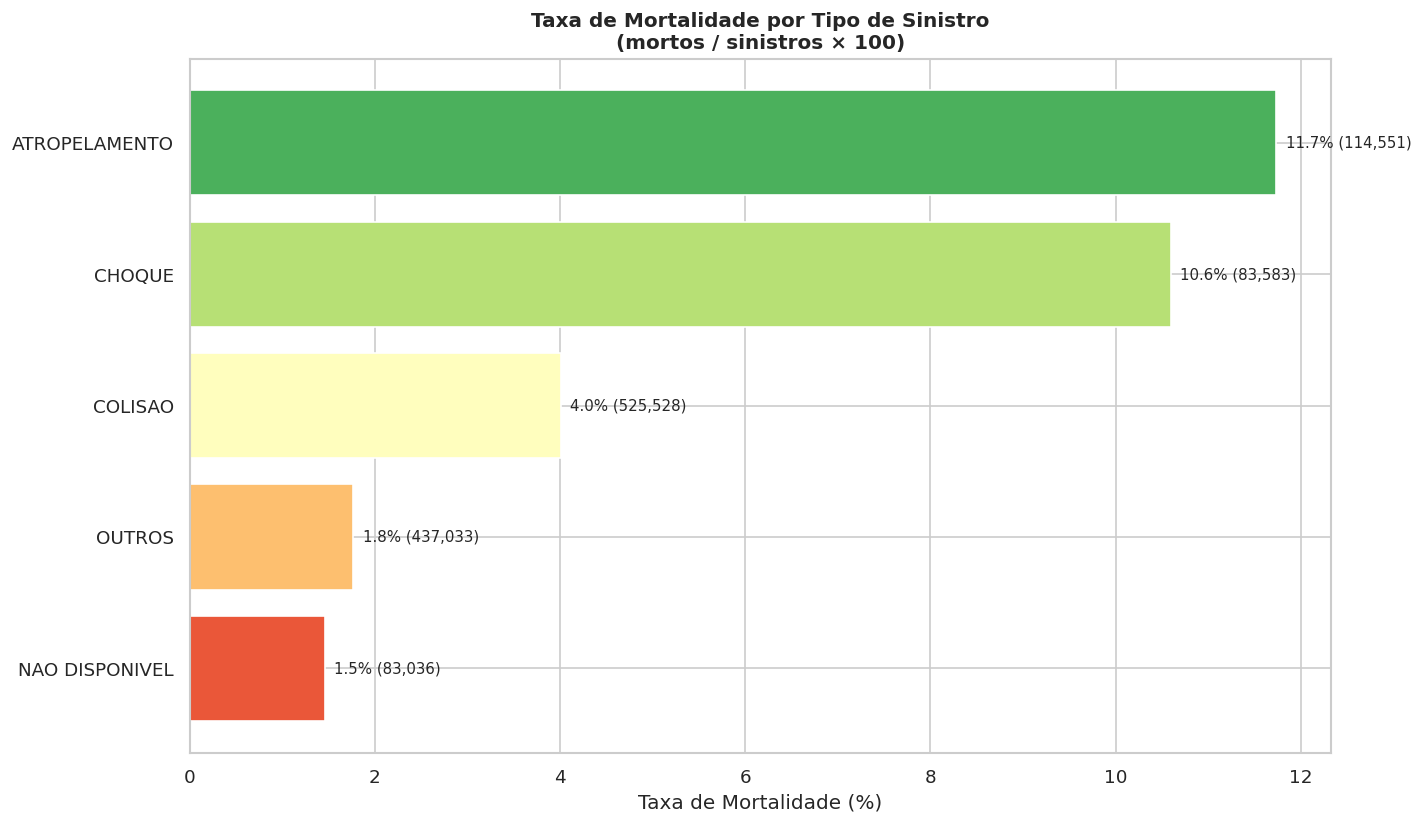

In [20]:
mortal = (
    df.groupby('tipo_acidente')
    .agg(sinistros=('id_sinistro','count'), mortos=('mortos','sum'))
    .assign(taxa=lambda x: x['mortos'] / x['sinistros'] * 100)
    .sort_values('taxa', ascending=False)
    .head(15).reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('RdYlGn_r', len(mortal))
bars = ax.barh(mortal['tipo_acidente'][::-1], mortal['taxa'][::-1], color=colors[::-1])
for bar, (_, row) in zip(bars, mortal[::-1].iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{row['taxa']:.1f}% ({int(row['sinistros']):,})",
            va='center', fontsize=9)
ax.set_title('Taxa de Mortalidade por Tipo de Sinistro\n(mortos / sinistros × 100)', fontweight='bold')
ax.set_xlabel('Taxa de Mortalidade (%)')
plt.tight_layout()
plt.savefig('mortalidade_tipo.png', bbox_inches='tight')
plt.show()

## 13. Sazonalidade — Sinistros por Mês

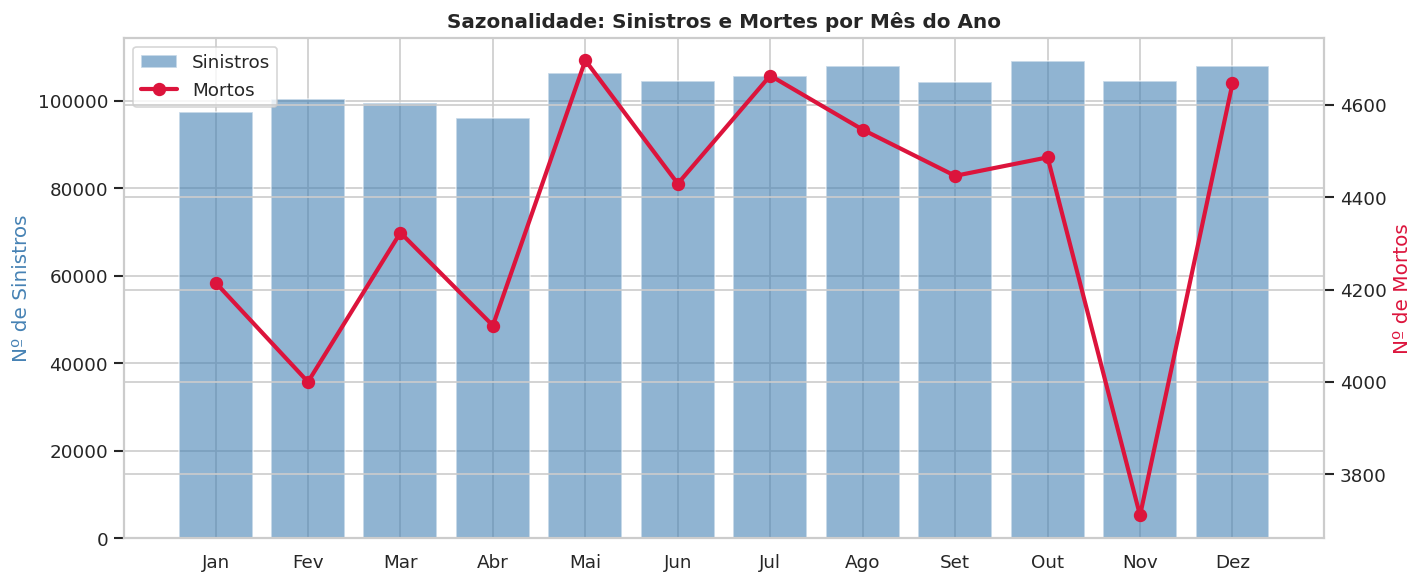

In [22]:
meses_nome = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
               7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
sazon = df.groupby('mes').agg(sinistros=('id_sinistro','count'), mortos=('mortos','sum')).reset_index()
sazon['mes_nome'] = sazon['mes'].map(meses_nome)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(sazon['mes_nome'], sazon['sinistros'], color='steelblue', alpha=0.6, label='Sinistros')
ax2.plot(sazon['mes_nome'], sazon['mortos'], color='crimson', lw=2.5, marker='o', ms=7, label='Mortos')
ax1.set_ylabel('Nº de Sinistros', color='steelblue')
ax2.set_ylabel('Nº de Mortos', color='crimson')
ax1.set_title('Sazonalidade: Sinistros e Mortes por Mês do Ano', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('sazonalidade.png', bbox_inches='tight')
plt.show()

---
## 14. Proposta de Análise

### Identificação de Zonas de Risco e Padrões Temporais de Sinistros Fatais no Estado de SP

#### Contextualização

A análise exploratória dos dados do Infosiga SP (2015–2026) revelou padrões relevantes:

- **Concentração geográfica:** sinistros se concentram fortemente em poucos municípios, especialmente na Região Metropolitana de SP e ao longo de rodovias estaduais.
- **Padrão temporal:** fins de semana e períodos noturnos concentram maior proporção de mortes.
- **Tipo de via:** vias de determinada classificação apresentam taxas de mortalidade desproporcionais.
- **Tipo de sinistro:** atropelamentos e colisões frontais têm as maiores taxas de mortalidade.
- **Sazonalidade:** meses específicos concentram picos consistentes de sinistros e mortes.

#### Proposta

**Realizar uma análise geoespacial de clustering para identificar zonas de alto risco no estado de SP,
cruzando a localização dos sinistros com fatores temporais (turno, dia, mês) e tipo de via,
com o objetivo de:**

1. **Mapear clusters de sinistros fatais** usando `ST_ClusterDBSCAN` do PostGIS para identificar
   corredores e interseções críticas no estado.

2. **Correlacionar clusters com tipo de via** (`causa_acidente`) para classificar se os pontos
   críticos estão em rodovias, vias urbanas ou outros tipos.

3. **Construir um índice de risco municipal** combinando densidade de sinistros por km²,
   taxa de mortalidade e sazonalidade via consultas espaciais no PostGIS.

4. **Analisar o perfil temporal dos clusters de alto risco** para identificar janelas críticas
   (ex.: madrugadas de sábado vs. horários de pico em dias úteis).

#### Viabilidade

- Dados históricos 2015–2026 coletados e armazenados no PostGIS
- Geometria dos municípios disponível para análises espaciais
- Coordenadas geográficas disponíveis para todos os sinistros filtrados
- Ferramentas: `geopandas`, `scikit-learn`, `folium`, PostGIS `ST_ClusterDBSCAN`

#### Pergunta central

> *"Quais são as zonas geográficas, os tipos de via e os turnos de maior risco de sinistro fatal
> no estado de SP, e como esses fatores se combinam para definir perfis de risco que possam
> orientar políticas públicas de segurança viária?"*